# ♻️ Waste Classification with Deep Learning
This notebook trains **MobileNetV2** and **ResNet50** on a TrashNet-style dataset and exports a model for a Streamlit app.

In [4]:
# 0) Environment Check & Installs
# GPU check
!nvidia-smi || echo "No GPU (still fine for small training)."

# Tools + libs compatible with Python 3.12
!pip -q install --upgrade pip setuptools wheel
!pip -q install "tensorflow==2.19.*" scikit-learn matplotlib seaborn opencv-python pillow


/bin/bash: line 1: nvidia-smi: command not found
No GPU (still fine for small training).


In [5]:
# 1) Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
# 2) Unzip dataset from Drive

import zipfile, os
zip_path = "/content/drive/MyDrive/datasets/trashnet.zip"
dst_dir = "/content/datasets"
os.makedirs(dst_dir, exist_ok=True)
if os.path.exists(zip_path):
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(dst_dir)
        print("Unzipped to", dst_dir)
else:
    print("Zip not found at", zip_path, "— skip if using folders directly in Drive.")


Unzipped to /content/datasets


In [7]:
# 3) Point DATA_DIR to your dataset
import os

DATA_DIR = "/content/datasets/trashnet"

print("DATA_DIR:", DATA_DIR)
if os.path.exists(DATA_DIR):
    print("Classes:", os.listdir(DATA_DIR))
else:
    print("WARNING: DATA_DIR not found. Please update the path above.")


DATA_DIR: /content/datasets/trashnet
Classes: ['paper', 'trash', 'glass', 'metal', '.DS_Store', 'plastic', 'cardboard']


In [8]:
# 4) Build datasets
import tensorflow as tf, json
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="training", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR, validation_split=0.2, subset="validation", seed=SEED,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)

# Save labels.json for Streamlit
with open("/content/labels.json", "w") as f:
    json.dump(class_names, f)
print("Saved /content/labels.json")


Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Saved /content/labels.json


In [9]:
# 5) Data augmentation
from tensorflow import keras
from tensorflow.keras import layers

data_augment = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="augment")


In [10]:
# 6) Train MobileNetV2 (fast)
base = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE+(3,), include_top=False, weights="imagenet"
)
base.trainable = False

inputs = keras.Input(shape=IMG_SIZE+(3,))
x = data_augment(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
mnv2 = tf.keras.Model(inputs, outputs, name="waste_mobilenetv2")

mnv2.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_mnv2 = mnv2.fit(train_ds, validation_data=val_ds, epochs=8)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.3931 - loss: 1.5891 - val_accuracy: 0.7287 - val_loss: 0.8235
Epoch 2/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.7312 - loss: 0.7298 - val_accuracy: 0.7663 - val_loss: 0.6436
Epoch 3/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.7832 - loss: 0.6172 - val_accuracy: 0.7842 - val_loss: 0.5966
Epoch 4/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 154s 2s/step - accuracy: 0.7996 - loss: 0.5459 - val_accuracy: 0.8000 - val_loss: 0.5611
Epoch 5/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.8273 - loss: 0.4986 - val_accuracy: 0.8119 - val_loss: 0.5224
Epoch 6/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.8492 - loss: 0.4240 - val_accuracy: 0.8218 - val_loss: 0.5244
Epoch 7/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.8568 - loss: 0.4350 - val_accuracy: 0.8218 - val_loss: 0.4989
Epoch 8/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.8652 

In [11]:
# 6b) fine-tune top layers
base.trainable = True
for layer in base.layers[:-40]:
    layer.trainable = False
mnv2.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
             loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_ft_mnv2 = mnv2.fit(train_ds, validation_data=val_ds, epochs=5)


Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 184s 3s/step - accuracy: 0.7640 - loss: 0.6750 - val_accuracy: 0.8238 - val_loss: 0.4823
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 167s 3s/step - accuracy: 0.8347 - loss: 0.5141 - val_accuracy: 0.8297 - val_loss: 0.4852
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 172s 3s/step - accuracy: 0.8465 - loss: 0.4755 - val_accuracy: 0.8376 - val_loss: 0.4889
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 168s 3s/step - accuracy: 0.8464 - loss: 0.4674 - val_accuracy: 0.8475 - val_loss: 0.4881
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 201s 3s/step - accuracy: 0.8597 - loss: 0.4055 - val_accuracy: 0.8475 - val_loss: 0.4763


In [13]:
# 7) Train ResNet50 (more accurate)
base2 = tf.keras.applications.ResNet50(
    input_shape=IMG_SIZE+(3,), include_top=False, weights="imagenet"
)
base2.trainable = False

inputs = tf.keras.Input(shape=IMG_SIZE+(3,))
x = data_augment(inputs)
x = tf.keras.applications.resnet50.preprocess_input(x)
x = base2(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
resnet = tf.keras.Model(inputs, outputs, name="waste_resnet50")

resnet.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_resnet = resnet.fit(train_ds, validation_data=val_ds, epochs=8)


Epoch 1/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 503s 8s/step - accuracy: 0.4997 - loss: 1.3879 - val_accuracy: 0.8178 - val_loss: 0.5519
Epoch 2/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 547s 8s/step - accuracy: 0.7977 - loss: 0.5387 - val_accuracy: 0.8396 - val_loss: 0.4522
Epoch 3/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 512s 8s/step - accuracy: 0.8326 - loss: 0.4453 - val_accuracy: 0.8436 - val_loss: 0.4492
Epoch 4/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 553s 8s/step - accuracy: 0.8360 - loss: 0.4362 - val_accuracy: 0.8574 - val_loss: 0.4095
Epoch 5/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 482s 8s/step - accuracy: 0.8764 - loss: 0.3231 - val_accuracy: 0.8653 - val_loss: 0.3765
Epoch 6/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 503s 8s/step - accuracy: 0.9092 - loss: 0.2648 - val_accuracy: 0.8535 - val_loss: 0.3978
Epoch 7/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 531s 8s/step - accuracy: 0.9024 - loss: 0.2614 - val_accuracy: 0.8594 - val_loss: 0.3924
Epoch 8/8
64/64 ━━━━━━━━━━━━━━━━━━━━ 513s 8s/step - accuracy: 0.9269 - loss: 0.2390 - val_accuracy: 0.8713 - val_loss:

In [14]:
# 7b) Fine-tune
base2.trainable = True
for layer in base2.layers[:-30]:
    layer.trainable = False
resnet.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
               loss="sparse_categorical_crossentropy", metrics=["accuracy"])
hist_ft_resnet = resnet.fit(train_ds, validation_data=val_ds, epochs=5)


Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 672s 10s/step - accuracy: 0.8750 - loss: 0.3510 - val_accuracy: 0.8634 - val_loss: 0.3731
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 701s 11s/step - accuracy: 0.9147 - loss: 0.2374 - val_accuracy: 0.8812 - val_loss: 0.3517
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 701s 11s/step - accuracy: 0.9479 - loss: 0.1941 - val_accuracy: 0.8891 - val_loss: 0.3540
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 693s 10s/step - accuracy: 0.9460 - loss: 0.1601 - val_accuracy: 0.8832 - val_loss: 0.3504
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 700s 11s/step - accuracy: 0.9670 - loss: 0.1315 - val_accuracy: 0.8911 - val_loss: 0.3386


MobileNetV2 classification report:
               precision    recall  f1-score   support

           0       0.94      0.84      0.89        69
           1       0.85      0.88      0.87       102
           2       0.77      0.91      0.83        88
           3       0.88      0.92      0.90       123
           4       0.85      0.79      0.82        89
           5       0.77      0.50      0.61        34

    accuracy                           0.85       505
   macro avg       0.84      0.81      0.82       505
weighted avg       0.85      0.85      0.84       505

ResNet50 classification report:
               precision    recall  f1-score   support

           0       0.91      0.91      0.91        69
           1       0.87      0.91      0.89       102
           2       0.83      0.91      0.87        88
           3       0.94      0.93      0.94       123
           4       0.92      0.82      0.87        89
           5       0.81      0.76      0.79        34

    accu

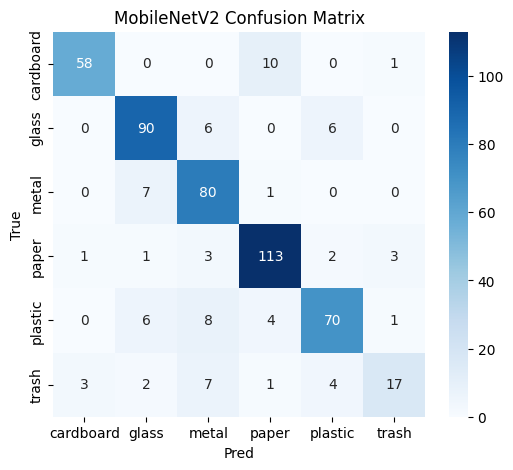

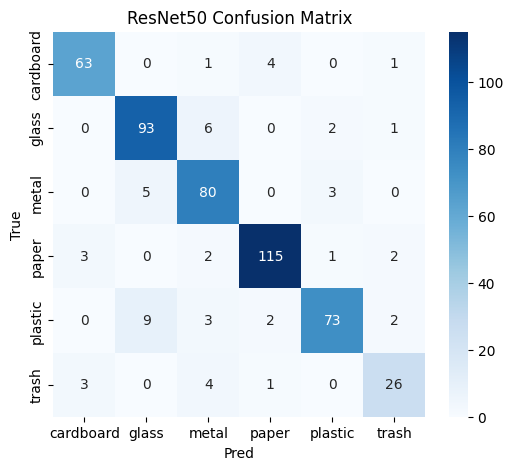

In [15]:
# 8) Evaluate + Confusion Matrices
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt, seaborn as sns

def evaluate_model(model, ds):
    y_true, y_pred = [], []
    for images, labels in ds.unbatch().batch(64):
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)

y_true_m, y_pred_m = evaluate_model(mnv2, val_ds)
y_true_r, y_pred_r = evaluate_model(resnet, val_ds)

print("MobileNetV2 classification report:\n",
      classification_report(y_true_m, y_pred_m, target_names=[str(c) for c in range(num_classes)]))
print("ResNet50 classification report:\n",
      classification_report(y_true_r, y_pred_r, target_names=[str(c) for c in range(num_classes)]))

def plot_cm(y_true, y_pred, title, class_names):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title); plt.ylabel('True'); plt.xlabel('Pred')
    plt.show()

plot_cm(y_true_m, y_pred_m, "MobileNetV2 Confusion Matrix", class_names)
plot_cm(y_true_r, y_pred_r, "ResNet50 Confusion Matrix", class_names)


In [17]:
# 9b) Save the best model + labels to Drive
import numpy as np, os, json
SAVE_DIR = "/content/drive/MyDrive/waste_project"
os.makedirs(SAVE_DIR, exist_ok=True)

acc_m = np.mean(y_true_m == y_pred_m)
acc_r = np.mean(y_true_r == y_pred_r)
best_model = resnet if acc_r >= acc_m else mnv2
model_name = best_model.name + ".h5"
best_model.save(os.path.join(SAVE_DIR, model_name))

with open("/content/labels.json") as f:
    labels = json.load(f)
with open(os.path.join(SAVE_DIR, "labels.json"), "w") as f:
    json.dump(labels, f)

print("Saved model to:", os.path.join(SAVE_DIR, model_name))
print("Saved labels to:", os.path.join(SAVE_DIR, "labels.json"))


Saved model to: /content/drive/MyDrive/waste_project/waste_resnet50.h5
Saved labels to: /content/drive/MyDrive/waste_project/labels.json


In [18]:
# 9a) Save the best model + labels to Drive

# pick your best model as before:
best_model = resnet if acc_r >= acc_m else mnv2

# save in Keras v3 format
SAVE_DIR = "/content/drive/MyDrive/waste_project"
best_model.save(f"{SAVE_DIR}/waste_model.keras")  # <- NEW
import json
with open(f"{SAVE_DIR}/labels.json","w") as f:
    json.dump(class_names, f)
